# Here is the link to RRP Analytics' Video Presentation on Customer Churn:

# 1.  Load all of the necessary libraries

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils import resample

# 2. Load the Datasets

In [ ]:
# Next we Loaded our dataset
train_data = pd.read_csv('/content/train.csv')
test_data = pd.read_csv('/content/test.csv')



# 3. Data Exploration and Preprocessing 1


TRAINING DATA INFO (5634, 21)
Duplicates:  0
Nulls:  8

TEST DATA INFO (1409, 20)
Duplicates:  0
Nulls:  3

TRAINING DATA INFO
id                     int64
gender                object
senior_citizen         int64
partner               object
dependents            object
tenure                 int64
phone_service         object
multiple_lines        object
internet_service      object
online_security       object
online_backup         object
device_protection     object
tech_support          object
streaming_tv          object
streaming_movies      object
contract              object
paperless_billing     object
payment_method        object
monthly_charges      float64
total_charges        float64
label                  int64
dtype: object

TEST DATA INFO
id                     int64
gender                object
senior_citizen         int64
partner               object
dependents            object
tenure                 int64
phone_service         object
multiple_lines        object
i

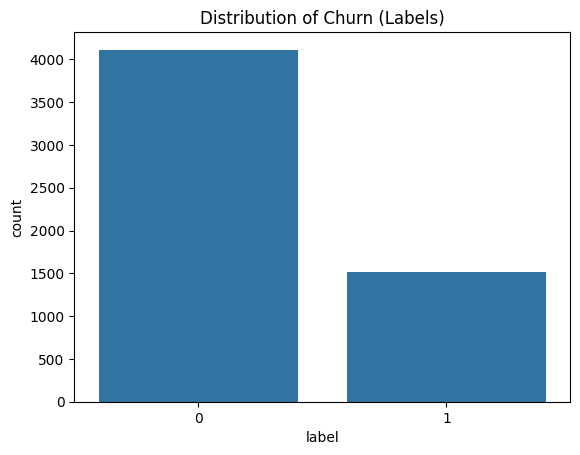

                id  senior_citizen       tenure  monthly_charges  \
count  5634.000000     5634.000000  5634.000000      5634.000000   
mean   3512.246539        0.161874    32.277955        64.779127   
std    2039.795966        0.368368    24.555211        30.104993   
min       1.000000        0.000000     0.000000        18.250000   
25%    1730.250000        0.000000     9.000000        35.400000   
50%    3518.500000        0.000000    29.000000        70.375000   
75%    5277.750000        0.000000    55.000000        89.850000   
max    7043.000000        1.000000    72.000000       118.650000   

       total_charges        label  
count    5626.000000  5634.000000  
mean     2280.662380     0.269968  
std      2266.394623     0.443982  
min        18.800000     0.000000  
25%       391.900000     0.000000  
50%      1394.800000     0.000000  
75%      3794.487500     1.000000  
max      8684.800000     1.000000  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries,

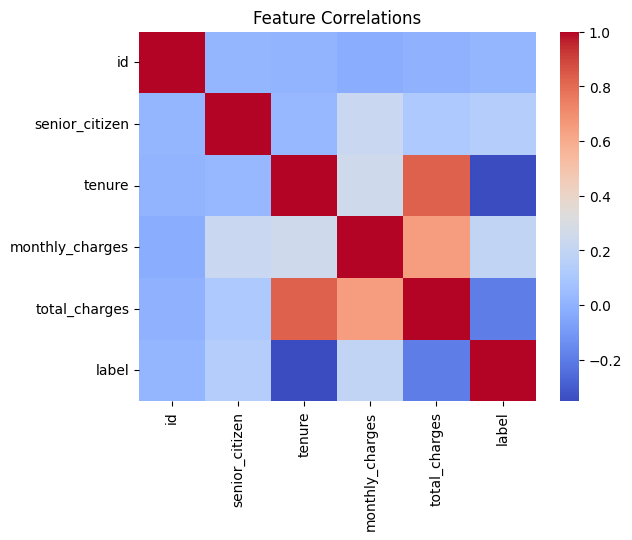

                       id  senior_citizen    tenure  monthly_charges  \
id               1.000000        0.014704  0.003617        -0.023486   
senior_citizen   0.014704        1.000000  0.023443         0.225234   
tenure           0.003617        0.023443  1.000000         0.251072   
monthly_charges -0.023486        0.225234  0.251072         1.000000   
total_charges   -0.005655        0.109925  0.828001         0.650821   
label            0.013765        0.141966 -0.351885         0.196805   

                 total_charges     label  
id                   -0.005655  0.013765  
senior_citizen        0.109925  0.141966  
tenure                0.828001 -0.351885  
monthly_charges       0.650821  0.196805  
total_charges         1.000000 -0.197416  
label                -0.197416  1.000000  


In [ ]:

# Here we replaced  missing values with null values, if present
train_data.replace(" ", np.nan, inplace=True)
test_data.replace(" ", np.nan, inplace=True)

# Blank spaces present in total charges, so need to force correct type
train_data['total_charges'] = train_data['total_charges'].astype(float)
test_data['total_charges'] = test_data['total_charges'].astype(float)

# Here we checked both datasets for datatypes, duplicates, and nulls
print('\nTRAINING DATA INFO', train_data.shape)
print('Duplicates: ', train_data.duplicated().sum())
print('Nulls: ', train_data.isnull().sum().sum())
print('\nTEST DATA INFO', test_data.shape)
print('Duplicates: ', test_data.duplicated().sum())
print('Nulls: ', test_data.isnull().sum().sum())
print('\nTRAINING DATA INFO')
print(train_data.dtypes)
print('\nTEST DATA INFO')
print(test_data.dtypes)


# Next we counted the number of columns to determine the number of features
print('\nSHARED COLUMNS')
print(train_data.dtypes)
print('\nNumber of Features: ', len(train_data.columns) - 2)

# Here we explored the distribution in the target
sns.countplot(x='label', data=train_data)
plt.title("Distribution of Churn (Labels)")
plt.show()

# Next we conducted summary statistics on the train dataset
print(train_data.describe())
print(train_data.info())

# Here we calculauted and visualized the correlation matrix for numeric columns
numeric_data = train_data.select_dtypes(include=['number'])
correlation_matrix = numeric_data.corr()
sns.heatmap(correlation_matrix, cmap="coolwarm")
plt.title("Feature Correlations")
plt.show()
print(correlation_matrix)

In [ ]:
print(train_data.columns)
print(test_data.columns)


Index(['id', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'label'],
      dtype='object')
Index(['id', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges'],
      dtype='object')


In [ ]:
print(train_data['contract'].unique())
print(test_data['contract'].unique())


['Two year' 'One year' 'Month-to-month']
['One year' 'Two year' 'Month-to-month']


In [ ]:
print(train_data.columns)

Index(['gender', 'senior_citizen', 'partner', 'dependents', 'tenure',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'label'],
      dtype='object')


# 4. Data Preprocessing 2




In [ ]:

# First, we dropped the 'id' column and saved it for later
train_ids = train_data.pop('id')
test_ids = test_data.pop('id')

# Next we seperated the features and target
X = train_data.drop(columns=['label'])  # Features
y = train_data['label']  # Target

# Here we verified that X and y match in shape before splitting
print(f"Shape of X: {X.shape}")  # Should be (number of samples, number of features)
print(f"Shape of y: {y.shape}")  # Should be (number of samples,)

# Here we handled class imbalance in the training data by resampling the minority class (churn)
X_up, y_up = resample(X[y == 1],
                      y[y == 1],
                      replace=True,
                      n_samples=X[y == 0].shape[0],
                      random_state=42)  # Added random_state for reproducibility

# Here we created a balanced dataset
X_bal = pd.concat([X[y == 0], X_up])  # Combined the majority class and upsampled minority class
y_bal = pd.concat([y[y == 0], y_up])  # Same for the target variable

# Here we split the data into training and validation sets (80-20 split), stratified to maintain class balance
X_train, X_val, y_train, y_val = train_test_split(X_bal, y_bal, test_size=0.2, stratify=y_bal, random_state=42)

# We esnured that X_train and y_train matched in shape before preprocessing
print(f"Shape of X_train: {X_train.shape}")  # Should match y_train.shape[0]
print(f"Shape of y_train: {y_train.shape}")  # Should match X_train.shape[0]


# We dinfed the preprocessing pipeline (handling numerical and categorical data)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),  # Impute missing values with the mean
            ('scaler', StandardScaler())  # Standardize numerical features
        ]), X.select_dtypes(exclude=['object']).columns),  # Automatically select numerical columns
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),  # Impute missing categorical values with the most frequent value
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # One-hot encoding for categorical columns
        ]), X.select_dtypes(include=['object']).columns)  # Automatically select categorical columns
    ]
)

# Here we applied the preprocessing pipeline to training and validation sets
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

# Next we checked the shape of processed data
print(f"Shape of X_train_processed: {X_train_processed.shape}")
print(f"Shape of X_val_processed: {X_val_processed.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_val: {y_val.shape}")

# Finally, we prepared the test data with the same preprocessing steps
X_test_processed = preprocessor.transform(test_data)  # Test set preprocessing without fitting

# Print shapes for final validation
print(f"Shape of X_test_processed: {X_test_processed.shape}")



























Shape of X: (5634, 19)
Shape of y: (5634,)
Shape of X_train: (6580, 19)
Shape of y_train: (6580,)
Shape of X_train_processed: (6580, 45)
Shape of X_val_processed: (1646, 45)
Shape of y_train: (6580,)
Shape of y_val: (1646,)
Shape of X_test_processed: (1409, 45)


# 5. Modeling Training

In [ ]:
from sklearn.linear_model import Perceptron
# First we define the Perceptron classifier pipeline
pipeline = Pipeline([
    ('classifier', Perceptron(max_iter=1000, random_state=42))  # Add the Perceptron classifier
])

# Next we fit the Perceptron classifier to the processed training data
pipeline.fit(X_train_processed, y_train)

# Finally, we evalaute the classifier on the validation set
y_pred_val = pipeline.predict(X_val_processed)
accuracy = accuracy_score(y_val, y_pred_val)
f1 = f1_score(y_val, y_pred_val, average='macro')

print("Accuracy:", accuracy)
print("F1-score (macro):", f1)






Accuracy: 0.6792223572296476
F1-score (macro): 0.6782170959386149


In [ ]:

# First, we defined the Logistic Regression classifier pipeline
pipeline = Pipeline([
    ('classifier', LogisticRegression(
        penalty='l2',                  # L2 regularization
        solver='lbfgs',                # LBFGS solver
        max_iter=10000,                # Maximum iterations set to 10,000
        random_state=42                # Set random state for reproducibility
    ))
])

# Next we fit the Logistic Regression classifier to the processed training data
pipeline.fit(X_train_processed, y_train)

# Finally, we evaluate the classifier on the validation set
y_pred_val = pipeline.predict(X_val_processed)
accuracy = accuracy_score(y_val, y_pred_val)
f1 = f1_score(y_val, y_pred_val, average='macro')

print("Accuracy:", accuracy)
print("F1-score (macro):", f1)

Accuracy: 0.755771567436209
F1-score (macro): 0.7553782680705075


In [ ]:

# First, we defined the Random Forest classifier pipeline
pipeline = Pipeline([
    ('classifier', RandomForestClassifier(
        n_estimators=100,              # Number of trees in the forest
        criterion='gini',              # Split criterion ('gini' or 'entropy')
        max_depth=None,                # Maximum depth of the trees
        random_state=42,               # Set random state for reproducibility
        n_jobs=-1                      # Use all available processors
    ))
])

# Next, we fit the Random Forest classifier to the processed training data
pipeline.fit(X_train_processed, y_train)

# Finally, we evalute the classifier on the validation set
y_pred_val = pipeline.predict(X_val_processed)
accuracy = accuracy_score(y_val, y_pred_val)
f1 = f1_score(y_val, y_pred_val, average='macro')

print("Accuracy:", accuracy)
print("F1-score (macro):", f1)






Accuracy: 0.8991494532199271
F1-score (macro): 0.8988603672232316


In [ ]:

# First, we define the KNN classifier pipeline
pipeline = Pipeline([
    ('classifier', KNeighborsClassifier(
        n_neighbors=5,              # Number of neighbors to use
        algorithm='auto',           # Algorithm to compute the nearest neighbors (auto selects the best)
        n_jobs=-1))                 # Use all processors for training
])

# Next, we fit the KNN classifier to the processed training data
pipeline.fit(X_train_processed, y_train)

# Finally, we evaluate the classifier on the validation set
y_pred_val = pipeline.predict(X_val_processed)
accuracy = accuracy_score(y_val, y_pred_val)
f1 = f1_score(y_val, y_pred_val, average='macro')

print("Accuracy:", accuracy)
print("F1-score (macro):", f1)





Accuracy: 0.7612393681652491
F1-score (macro): 0.7585723898787298


In [ ]:
import xgboost as xgb
# First we define the XGBoost classifier pipeline
pipeline = Pipeline([
    ('classifier', xgb.XGBClassifier(
        objective='binary:logistic',  # Binary classification objective
        eval_metric='logloss',        # Evaluation metric
        use_label_encoder=False,      # Prevent warning related to label encoding
        random_state=42,              # Set random state for reproducibility
        n_estimators=100,            # Number of boosting rounds
        max_depth=6,                 # Maximum depth of trees
        learning_rate=0.1,           # Learning rate (shrinkage)
        subsample=0.8,               # Subsample ratio of the training set
        colsample_bytree=0.8         # Subsample ratio of features for each tree
    ))
])

# Next, we Fit the XGBoost classifier to the processed training data
pipeline.fit(X_train_processed, y_train)

# Finaly, we evaluate the classifier on the validation set
y_pred_val = pipeline.predict(X_val_processed)
accuracy = accuracy_score(y_val, y_pred_val)
f1 = f1_score(y_val, y_pred_val, average='macro')

print("Accuracy:", accuracy)
print("F1-score (macro):", f1)





Accuracy: 0.8353584447144593
F1-score (macro): 0.8347112154079712


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [20:43:52] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:

# First we define the Decision Tree classifier pipeline
pipeline = Pipeline([
    ('classifier', DecisionTreeClassifier(
        criterion='gini',             # Gini impurity for splitting nodes
        max_depth=5,                  # Maximum depth of the tree
        min_samples_split=10,         # Minimum samples required to split a node
        random_state=42))             # Set random state for reproducibility
])

# Next we fit the Decision Tree classifier to the processed training data
pipeline.fit(X_train_processed, y_train)

# Finally, we evaluate the classifier on the validation set
y_pred_val = pipeline.predict(X_val_processed)
accuracy = accuracy_score(y_val, y_pred_val)
f1 = f1_score(y_val, y_pred_val, average='macro')

print("Accuracy:", accuracy)
print("F1-score (macro):", f1)


Accuracy: 0.7509113001215066
F1-score (macro): 0.7493477976657397


# 6. Training the best model on the full test set and predicitng probabilites
  * The best model was the Random Forest Classifier with an accruact of 0.899 and a F1-score(macro) of 0.898




In [ ]:

# First, we define the Random Forest classifier pipeline
pipeline = Pipeline([
    ('classifier', RandomForestClassifier(
        n_estimators=100,              # Number of trees in the forest
        criterion='gini',              # Split criterion ('gini' or 'entropy')
        max_depth=None,                # Maximum depth of the trees
        random_state=42,               # Set random state for reproducibility
        n_jobs=-1                      # Use all available processors
    ))
])

# Next we combined the training and validation data for full model training
X_full_train = np.concatenate([X_train_processed, X_val_processed], axis=0)
y_full_train = np.concatenate([y_train, y_val], axis=0)

# Next we fit the Random Forest classifier to the full dataset
pipeline.fit(X_full_train, y_full_train)

# Next we predicted probabilities on the test set (test set does not have 'label')
y_pred_proba = pipeline.predict_proba(X_test_processed)

# As this is a binary classification, we will get probabilities for the positive class (class 1)
y_pred_proba_class1 = y_pred_proba[:, 1]

# Next, we created a submission DataFrame with the predicted probabilities
submission_df = pd.DataFrame({'id': test_ids, 'label': y_pred_proba_class1})

# Next, we saved the submission DataFrame to a CSV file
submission_df.to_csv('submission_proba.csv', index=False)

# Here, we wanted to  evaluate the model on the validation set
y_pred_val = pipeline.predict(X_val_processed)
accuracy = accuracy_score(y_val, y_pred_val)
f1 = f1_score(y_val, y_pred_val, average='macro')

# Print accuracy and F1 score
print("Accuracy:", accuracy)
print("F1-score (macro):", f1)




Accuracy: 0.9987849331713244
F1-score (macro): 0.9987849313774124


# 7. Learning Curve

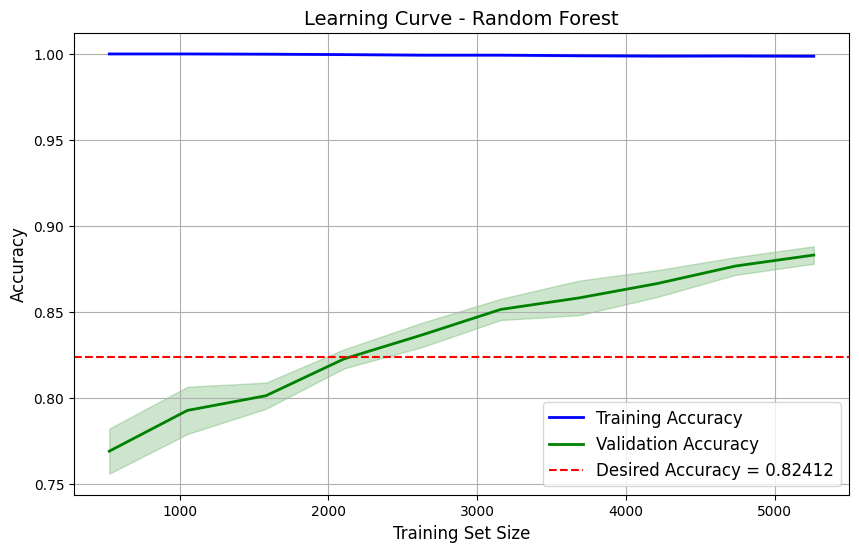

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import numpy as np

# Define the Random Forest classifier pipeline
pipeline = Pipeline([
    ('classifier', RandomForestClassifier(
        n_estimators=100,              # Number of trees in the forest
        criterion='gini',              # Split criterion ('gini' or 'entropy')
        max_depth=None,                # Maximum depth of the trees
        random_state=42,               # Set random state for reproducibility
        n_jobs=-1                      # Use all available processors
    ))
])

# Get learning curve data using training data for training and cross-validation
train_sizes, train_scores, test_scores = learning_curve(
    pipeline, X_train_processed, y_train, cv=5, n_jobs=-1,
    train_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
)

# Calculate the mean and standard deviation of training and testing scores
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(train_sizes, test_mean, label='Validation Accuracy', color='green', linewidth=2)

# Plot the shaded regions for the standard deviation of training and testing scores
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color='green')

# Add a desired accuracy line if needed (e.g., 0.82412)
plt.axhline(y=0.82412, color='red', linestyle='--', label='Desired Accuracy = 0.82412')

# Add labels, title, and legend
plt.title('Learning Curve - Random Forest', fontsize=14)
plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='best', fontsize=12)
plt.grid(True)

# Display the plot
plt.show()





# 7. Discussion
  * When we trained the Radom Forest classifier on the full training set the accuracy out was 0.998 and the F1-score (macro) was also 0.998.
  * In analysing the learing curve we acknowldge that there may be some overfitting, however, due to the fact that the model gernalized quit favorable we did not see an issue in deploying.
  * This notebook is one of many that RRP Analytics used to experiment with different preporcessing work flows and pipline incorporation.
  * Due to the skewed class distrubtion towards 0(non-churners) we had to incoporate some class blancing techniques.
  * Further, we ensured that the shape of the data sets were compatably as to not run into any issues when generalizing.